### Tune Multi-Objective Penalty Weights

Quick grid search to find optimal penalty weights for the multi-objective approach.

In [1]:

import numpy as np
import pandas as pd
from pathlib import Path
import json
import sys
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

# Import the multi-objective training function
from multi_objective import train_multi_objective

print("✅ All imports loaded successfully!")
print("Ready to run grid search or quick comparison.")


✅ All imports loaded successfully!
Ready to run grid search or quick comparison.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
def grid_search_penalties(
    agent_type='technical',
    algorithm='PPO',  # 'PPO' (fast), 'SAC' (slow but good), 'A2C' (fast)
    
    # RETURN SCALE: How much to prioritize returns vs penalties
    # - Higher (8+): Aggressive, chases returns
    # - Lower (3-5): Conservative, prioritizes risk controls  
    return_scales=[3.0, 5.0, 8.0],
    
    # VOLATILITY PENALTY: Penalizes volatile returns (risk control)
    # Formula: -λ_vol × |return - mean_return|
    # - Higher: Prefers stable returns
    # - Lower: Allows higher volatility
    vol_penalties=[0.05, 0.1, 0.2],
    
    # CONCENTRATION PENALTY: Forces diversification
    # Formula: -λ_conc × max(0, max_weight - 0.3)
    # - Only penalizes if ANY asset > 30%
    # - Higher: More equal weight distribution
    # - Lower: Allows concentrated positions
    conc_penalties=[0.25, 0.5],
    
    # TURNOVER PENALTY: Discourages excessive trading (transaction cost proxy)
    # Formula: -λ_turn × Σ|weights_t - weights_{t-1}|
    # - Higher: Buy-and-hold, minimal rebalancing
    # - Lower/0: Active rebalancing
    turn_penalties=[0.0, 0.005, 0.01],
    
    quick_steps=50_000  # Training steps per config (reduced for speed)
):
    """
    Grid search over multi-objective reward penalty weights.
    
    Finds optimal balance between 4 components:
    1. Return maximization (return_scale)
    2. Risk control (volatility penalty)  
    3. Diversification (concentration penalty)
    4. Transaction costs (turnover penalty)
    
    Total combinations: 3 × 3 × 2 × 3 = 54 configs (~30-45 min)
    
    Parameters
    ----------
    agent_type : str
        'technical' or 'sentiment'
    return_scales : list
        Return reward scale [3.0, 5.0, 8.0]
    vol_penalties : list
        Volatility penalty weights [0.05, 0.1, 0.2]
    conc_penalties : list
        Concentration penalty weights [0.25, 0.5]
    turn_penalties : list
        Turnover penalty weights [0.0, 0.005, 0.01]
    quick_steps : int
        Training steps per configuration
    
    Returns
    -------
    results_df : pd.DataFrame
        Results sorted by validation Sharpe
    best_config : tuple
        (return_scale, vol_penalty, conc_penalty, turn_penalty)
    """
    
    print("="*80)
    print(f"GRID SEARCH: {agent_type.upper()} AGENT | {algorithm}")
    print("="*80)
    print(f"Searching {len(return_scales)} × {len(vol_penalties)} × {len(conc_penalties)} × {len(turn_penalties)} = "
          f"{len(return_scales) * len(vol_penalties) * len(conc_penalties) * len(turn_penalties)} configurations")
    print()
    
    base_config = {
        'data_dir': '../../data_hierarchical',
        'models_dir': f'../../models/{agent_type}/multi_objective_tune',
        'total_steps': quick_steps,
        'eval_freq': 5_000,
        'patience': 3,  # Reduced patience for tuning
        'learning_rate': 3e-4,
        'gamma': 0.99,
        'softmax_temperature': 3.0,
        'vol_window': 12,
        'seed': 42,
    }
    
    Path(base_config['models_dir']).mkdir(exist_ok=True)
    
    results = []
    best_val_sharpe = -np.inf
    best_config = None
    best_test_sharpe = None
    
    # Grid search
    combinations = list(product(return_scales, vol_penalties, conc_penalties, turn_penalties))
    
    for idx, (ret_scale, vol_pen, conc_pen, turn_pen) in enumerate(combinations, 1):
        print(f"\n[{idx}/{len(combinations)}] Testing: Ret={ret_scale:.1f}, Vol={vol_pen:.3f}, Conc={conc_pen:.3f}, Turn={turn_pen:.3f}")
        
        config = base_config.copy()
        config.update({
            'return_scale': ret_scale,
            'volatility_penalty': vol_pen,
            'concentration_penalty': conc_pen,
            'turnover_penalty': turn_pen,
        })
        
        try:
            result = train_multi_objective(agent_type, algorithm, config, verbose=False)
            
            val_sharpe = result['val_sharpe']
            test_sharpe = result['test_sharpe']
            
            results.append({
                'return_scale': ret_scale,
                'volatility_penalty': vol_pen,
                'concentration_penalty': conc_pen,
                'turnover_penalty': turn_pen,
                'train_sharpe': result['train_sharpe'],
                'val_sharpe': val_sharpe,
                'test_sharpe': test_sharpe,
            })
            
            print(f"  → Val Sharpe: {val_sharpe:.3f}, Test Sharpe: {test_sharpe:.3f}")
            
            if val_sharpe > best_val_sharpe:
                best_val_sharpe = val_sharpe
                best_test_sharpe = test_sharpe
                best_config = (ret_scale, vol_pen, conc_pen, turn_pen)
                print(f"  ⭐ NEW BEST (by Val)!")
        
        except Exception as e:
            print(f"  ✗ Failed: {e}")
            continue
    
    # Results summary
    print("\n" + "="*80)
    print("GRID SEARCH COMPLETE")
    print("="*80)
    
    results_df = pd.DataFrame(results).sort_values('val_sharpe', ascending=False)
    
    print("\nTop 5 Configurations (by Val Sharpe):")
    print(results_df.head().to_string(index=False))
    
    print(f"\n🏆 BEST CONFIG (Selected by Val Sharpe):")
    print(f"   Return Scale:           {best_config[0]:.1f}")
    print(f"   Volatility Penalty:     {best_config[1]:.3f}")
    print(f"   Concentration Penalty:  {best_config[2]:.3f}")
    print(f"   Turnover Penalty:       {best_config[3]:.3f}")
    print(f"   Val Sharpe:             {best_val_sharpe:.3f}")
    print(f"   Test Sharpe:            {best_test_sharpe:.3f}")
    
    # Also show what would be best by test (for reference)
    results_df_by_test = results_df.sort_values('test_sharpe', ascending=False)
    best_by_test = results_df_by_test.iloc[0]
    print(f"\n📊 BEST BY TEST SHARPE (for reference only):")
    print(f"   Return Scale:           {best_by_test['return_scale']:.1f}")
    print(f"   Volatility Penalty:     {best_by_test['volatility_penalty']:.3f}")
    print(f"   Concentration Penalty:  {best_by_test['concentration_penalty']:.3f}")
    print(f"   Turnover Penalty:       {best_by_test['turnover_penalty']:.3f}")
    print(f"   Val Sharpe:             {best_by_test['val_sharpe']:.3f}")
    print(f"   Test Sharpe:            {best_by_test['test_sharpe']:.3f}")
    
    # Warning if they differ significantly
    if abs(best_test_sharpe - best_by_test['test_sharpe']) > 0.1:
        print(f"\n⚠️  WARNING: Best Val config has significantly lower Test Sharpe!")
        print(f"   This may indicate overfitting to validation set or distribution shift.")
        print(f"   Consider using the Best by Test config OR collecting more data.")
    
    # Save results
    results_path = Path(base_config['models_dir']) / f'tuning_results_{agent_type}.csv'
    results_df.to_csv(results_path, index=False)
    print(f"\nResults saved to: {results_path}")
    
    best_config_dict = {
        'agent_type': agent_type,
        'best_config': {
            'return_scale': best_config[0],
            'volatility_penalty': best_config[1],
            'concentration_penalty': best_config[2],
            'turnover_penalty': best_config[3],
        },
        'val_sharpe': best_val_sharpe,
        'all_results': results
    }
    
    json_path = Path(base_config['models_dir']) / f'best_config_{agent_type}.json'
    with open(json_path, 'w') as f:
        json.dump(best_config_dict, f, indent=2)
    
    return results_df, best_config


def quick_comparison(agent_type='technical', algorithm='PPO'):
    """
    Quick comparison of 4 representative penalty configurations.
    
    Tests diverse strategies in ~10-15 minutes:
    1. No Penalties - Aggressive return maximization
    2. Balanced - Moderate risk controls  
    3. Conservative - Strong penalties, prioritize stability
    4. Diversified & Stable - Force diversification, low turnover
    
    Use this for rapid testing before full grid search.
    """
    
    print("="*80)
    print("QUICK PENALTY COMPARISON")
    print("="*80)
    
    # Quick comparison of representative configs
    # Format: (return_scale, vol, conc, turn, name)
    configs = [
        # Baseline: No risk controls, pure return maximization
        (8.0, 0.0, 0.0, 0.0, "No Penalties (Aggressive)"),
        
        # Balanced: Moderate penalties across all components
        (5.0, 0.1, 0.25, 0.005, "Balanced"),
        
        # Conservative: Strong penalties, prioritize risk control
        (3.0, 0.2, 0.5, 0.01, "Conservative (Risk Control)"),
        
        # High diversification: Force equal weights, low turnover
        (5.0, 0.1, 0.5, 0.01, "Diversified & Stable"),
    ]
    
    print(f"Agent: {agent_type} | Algorithm: {algorithm}")
    print("="*60)
    
    base_config = {
        'data_dir': '../../data_hierarchical',
        'models_dir': f'../../models/{agent_type}/multi_objective_quick',
        'total_steps': 50_000,
        'eval_freq': 5_000,
        'patience': 3,
        'learning_rate': 3e-4,
        'gamma': 0.99,
        'softmax_temperature': 3.0,
        'vol_window': 12,
        'seed': 42,
    }
    
    Path(base_config['models_dir']).mkdir(exist_ok=True)
    
    results = []
    
    for ret_scale, vol_pen, conc_pen, turn_pen, name in configs:
        print(f"\n{name}: Ret={ret_scale}, Vol={vol_pen}, Conc={conc_pen}, Turn={turn_pen}")
        
        config = base_config.copy()
        config.update({
            'return_scale': ret_scale,
            'volatility_penalty': vol_pen,
            'concentration_penalty': conc_pen,
            'turnover_penalty': turn_pen,
        })
        
        result = train_multi_objective(agent_type, algorithm, config, verbose=False)
        
        results.append({
            'config': name,
            'return_scale': ret_scale,
            'volatility_penalty': vol_pen,
            'concentration_penalty': conc_pen,
            'turnover_penalty': turn_pen,
            'train_sharpe': result['train_sharpe'],
            'val_sharpe': result['val_sharpe'],
            'test_sharpe': result['test_sharpe'],
        })
        
        print(f"  Val: {result['val_sharpe']:.3f}, Test: {result['test_sharpe']:.3f}")
    
    print("\n" + "="*80)
    print("COMPARISON RESULTS")
    print("="*80)
    
    df = pd.DataFrame(results).sort_values('test_sharpe', ascending=False)
    print(df.to_string(index=False))
    
    return df


In [3]:
"""
EXECUTION CELL - Choose which mode to run

Set ONE of these to True:
- quick = True  : Quick comparison (4 configs, ~10-15 min)
- grid = True   : Full grid search (54 configs, ~30-45 min)
"""

quick = True   
grid = False
agent = 'technical'  # 'technical' or 'sentiment'

# Speed optimization: Use only PPO algorithm for faster testing
# PPO is fastest and performs well. Full comparison uses PPO, SAC, A2C.
algorithm = 'PPO'  # 'PPO' (fast), 'SAC' (slower), 'A2C' (fast but less stable)

if quick:
    # Quick comparison of hand-picked configs
    print("Running quick comparison...")
    print(f"Agent: {agent}")
    print(f"Algorithm: {algorithm} (fast testing)")
    print("Testing 4 representative penalty configurations\n")
    results = quick_comparison(agent_type=agent, algorithm=algorithm)

else:
    # Full grid search with tuned parameters
    print(f"Running grid search for {agent} agent...")
    print(f"Algorithm: {algorithm}")
    print("This will take 30-45 minutes depending on your hardware")
    print("Testing 3 × 3 × 2 × 3 = 54 configurations\n")
    
    results_df, best_config = grid_search_penalties(
        agent_type=agent,
        algorithm=algorithm,
        # Using tuned parameters from Cell 2 function defaults:
        # return_scales=[3.0, 5.0, 8.0]
        # vol_penalties=[0.05, 0.1, 0.2]
        # conc_penalties=[0.25, 0.5]
        # turn_penalties=[0.0, 0.005, 0.01]
        quick_steps=50_000
    )




Running quick comparison...
Agent: technical
Algorithm: PPO (fast testing)
Testing 4 representative penalty configurations

QUICK PENALTY COMPARISON
Agent: technical | Algorithm: PPO

No Penalties (Aggressive): Ret=8.0, Vol=0.0, Conc=0.0, Turn=0.0
MultiObjective-TechnicalEnv (train): 201 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (val): 66 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (test): 67 dates, 7 assets, 20 features
  Val: 2.782, Test: 1.030

Balanced: Ret=5.0, Vol=0.1, Conc=0.25, Turn=0.005
MultiObjective-TechnicalEnv (train): 201 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (val): 66 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (test): 67 dates, 7 assets, 20 features
  Val: 2.897, Test: 1.220

Conservative (Risk Control): Ret=3.0, Vol=0.2, Conc=0.5, Turn=0.01
MultiObjective-TechnicalEnv (train): 201 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (val): 66 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (test)

✅ Using results from quick_comparison() for technical agent


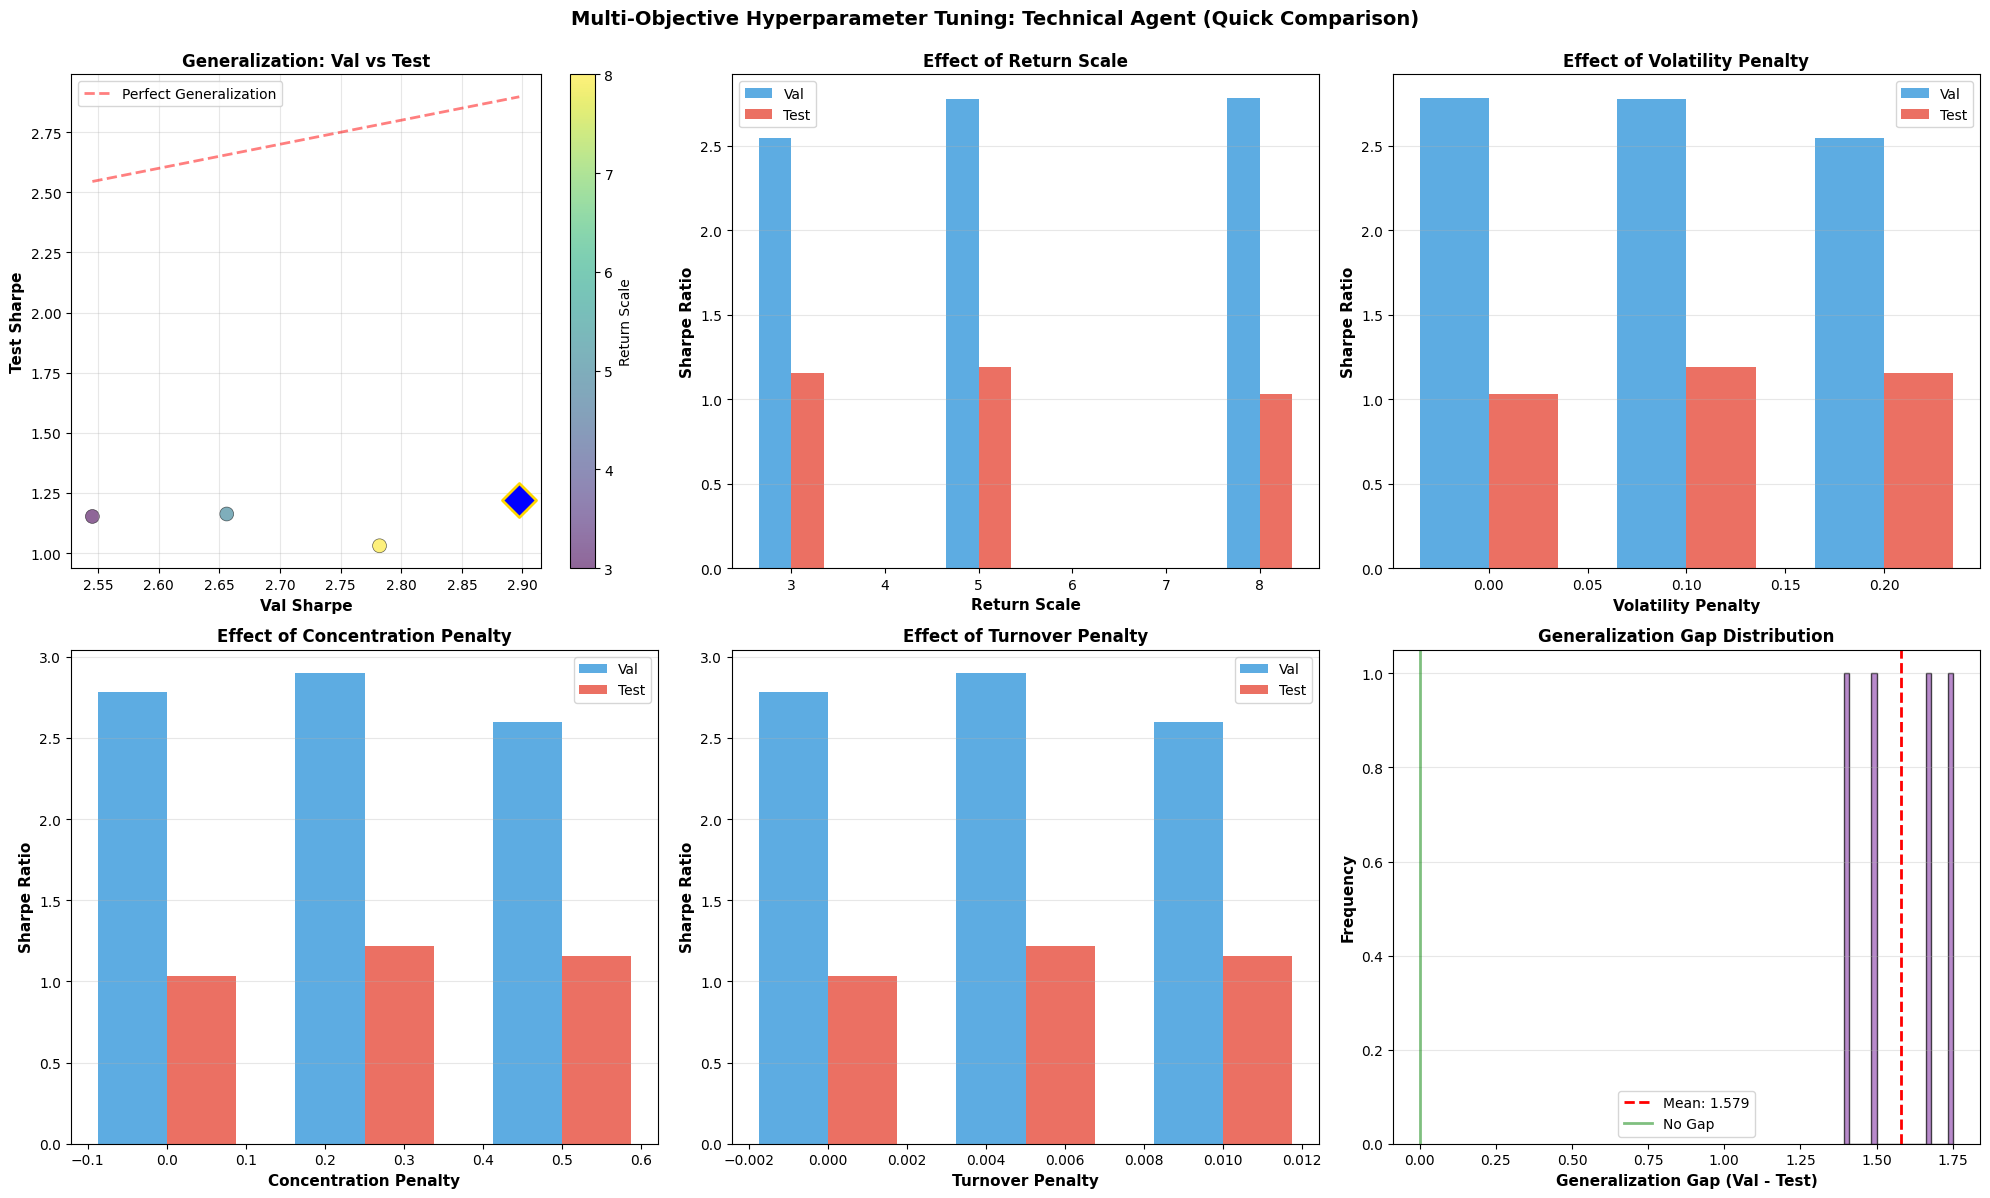

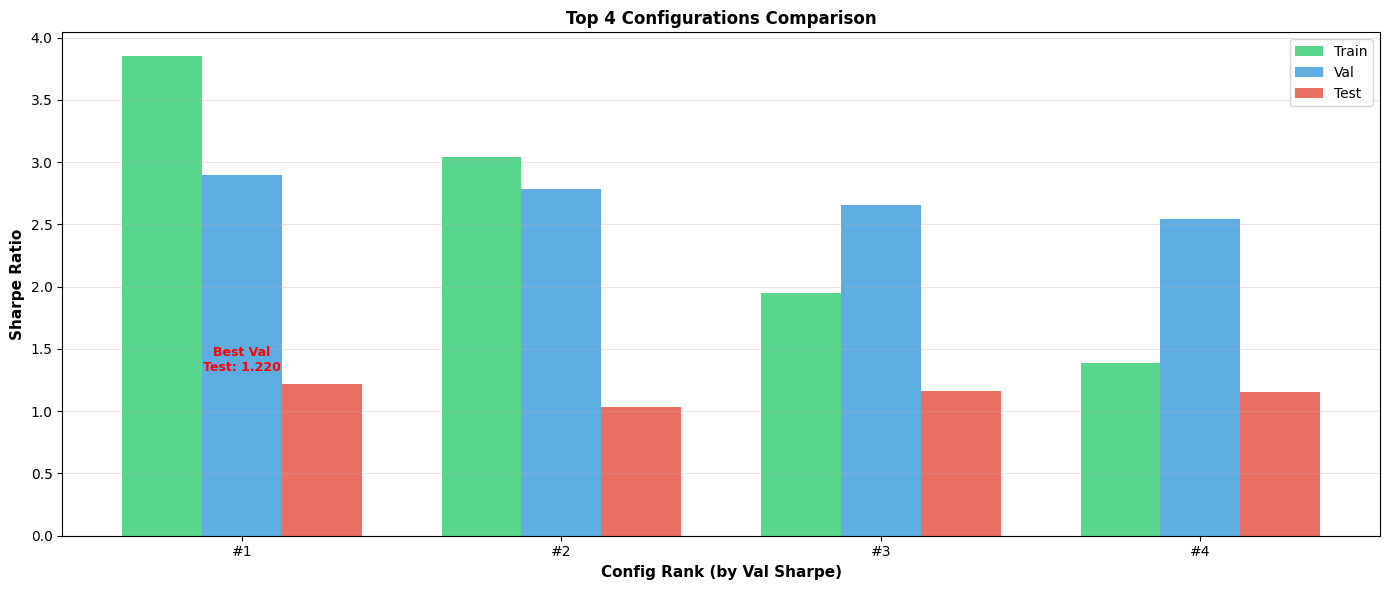


VISUALIZATION COMPLETE
Mode: Quick Comparison
Agent: Technical
Configurations tested: 4

Plots saved:
  1. ../../plots/tuning_technical_quick_comparison.png
  2. ../../plots/top_configs_technical_quick_comparison.png


In [4]:
# Load results from either quick comparison or grid search
# Check which variable exists and which mode was run
if 'results' in locals() and results is not None:
    df = results.copy()
    print(f"✅ Using results from quick_comparison() for {agent} agent")
    mode = "Quick Comparison"
elif 'results_df' in locals():
    df = results_df.copy()
    print(f"✅ Using results from grid_search_penalties() for {agent} agent")
    mode = "Grid Search"
else:
    print("❌ ERROR: No results found!")
    print("\nPlease run Cell 3 first:")
    print("  1. Set agent = 'technical' or 'sentiment'")
    print("  2. Set quick = True (or grid = True)")
    print("  3. Run the cell")
    print("  4. Wait for completion")
    print("  5. Then run this visualization cell")
    raise ValueError("No results available. Run Cell 3 first!")

# Verify agent variable exists
if 'agent' not in locals():
    agent = 'technical'  # Fallback default
    print(f"⚠️  Warning: Agent not specified, using default: {agent}")

# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Heatmap: Val vs Test Sharpe
ax1 = plt.subplot(2, 3, 1)
scatter = ax1.scatter(df['val_sharpe'], df['test_sharpe'], 
                        c=df['return_scale'], s=100, alpha=0.6, 
                        cmap='viridis', edgecolors='black', linewidth=0.5)
ax1.plot([df['val_sharpe'].min(), df['val_sharpe'].max()], 
            [df['val_sharpe'].min(), df['val_sharpe'].max()], 
            'r--', linewidth=2, alpha=0.5, label='Perfect Generalization')
ax1.set_xlabel('Val Sharpe', fontsize=11, fontweight='bold')
ax1.set_ylabel('Test Sharpe', fontsize=11, fontweight='bold')
ax1.set_title('Generalization: Val vs Test', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Return Scale', fontsize=10)

# Highlight best configs
best_val_idx = df['val_sharpe'].idxmax()
best_test_idx = df['test_sharpe'].idxmax()
ax1.scatter(df.loc[best_val_idx, 'val_sharpe'], 
            df.loc[best_val_idx, 'test_sharpe'], 
            s=300, c='red', marker='*', edgecolors='gold', linewidth=2,
            label='Best Val', zorder=5)
ax1.scatter(df.loc[best_test_idx, 'val_sharpe'], 
            df.loc[best_test_idx, 'test_sharpe'], 
            s=300, c='blue', marker='D', edgecolors='gold', linewidth=2,
            label='Best Test', zorder=5)

# 2. Return Scale Effect
ax2 = plt.subplot(2, 3, 2)
grouped = df.groupby('return_scale').agg({
    'val_sharpe': 'mean',
    'test_sharpe': 'mean'
})
x = grouped.index
width = 0.35
ax2.bar(x - width/2, grouped['val_sharpe'], width, label='Val', alpha=0.8, color='#3498db')
ax2.bar(x + width/2, grouped['test_sharpe'], width, label='Test', alpha=0.8, color='#e74c3c')
ax2.set_xlabel('Return Scale', fontsize=11, fontweight='bold')
ax2.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
ax2.set_title('Effect of Return Scale', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Volatility Penalty Effect
ax3 = plt.subplot(2, 3, 3)
grouped = df.groupby('volatility_penalty').agg({
    'val_sharpe': 'mean',
    'test_sharpe': 'mean'
})
x = grouped.index
width = (x[1] - x[0]) * 0.35 if len(x) > 1 else 0.02
ax3.bar(x - width/2, grouped['val_sharpe'], width, label='Val', alpha=0.8, color='#3498db')
ax3.bar(x + width/2, grouped['test_sharpe'], width, label='Test', alpha=0.8, color='#e74c3c')
ax3.set_xlabel('Volatility Penalty', fontsize=11, fontweight='bold')
ax3.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
ax3.set_title('Effect of Volatility Penalty', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Concentration Penalty Effect
ax4 = plt.subplot(2, 3, 4)
grouped = df.groupby('concentration_penalty').agg({
    'val_sharpe': 'mean',
    'test_sharpe': 'mean'
})
x = grouped.index
width = (x[1] - x[0]) * 0.35 if len(x) > 1 else 0.1
ax4.bar(x - width/2, grouped['val_sharpe'], width, label='Val', alpha=0.8, color='#3498db')
ax4.bar(x + width/2, grouped['test_sharpe'], width, label='Test', alpha=0.8, color='#e74c3c')
ax4.set_xlabel('Concentration Penalty', fontsize=11, fontweight='bold')
ax4.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
ax4.set_title('Effect of Concentration Penalty', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Turnover Penalty Effect
ax5 = plt.subplot(2, 3, 5)
grouped = df.groupby('turnover_penalty').agg({
    'val_sharpe': 'mean',
    'test_sharpe': 'mean'
})
x = grouped.index
width = (x[1] - x[0]) * 0.35 if len(x) > 1 else 0.002
ax5.bar(x - width/2, grouped['val_sharpe'], width, label='Val', alpha=0.8, color='#3498db')
ax5.bar(x + width/2, grouped['test_sharpe'], width, label='Test', alpha=0.8, color='#e74c3c')
ax5.set_xlabel('Turnover Penalty', fontsize=11, fontweight='bold')
ax5.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
ax5.set_title('Effect of Turnover Penalty', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Generalization Gap Distribution
ax6 = plt.subplot(2, 3, 6)
df['gap'] = df['val_sharpe'] - df['test_sharpe']
ax6.hist(df['gap'], bins=20, alpha=0.7, color='#9b59b6', edgecolor='black')
ax6.axvline(df['gap'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["gap"].mean():.3f}')
ax6.axvline(0, color='green', linestyle='-', linewidth=2, alpha=0.5, label='No Gap')
ax6.set_xlabel('Generalization Gap (Val - Test)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6.set_title('Generalization Gap Distribution', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Multi-Objective Hyperparameter Tuning: {agent.capitalize()} Agent ({mode})', 
                fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Additional: Top Configs Comparison
fig2, ax = plt.subplots(figsize=(14, 6))
top_n = min(10, len(df))
top_configs = df.nlargest(top_n, 'val_sharpe')

x = np.arange(top_n)
width = 0.25

ax.bar(x - width, top_configs['train_sharpe'], width, label='Train', alpha=0.8, color='#2ecc71')
ax.bar(x, top_configs['val_sharpe'], width, label='Val', alpha=0.8, color='#3498db')
ax.bar(x + width, top_configs['test_sharpe'], width, label='Test', alpha=0.8, color='#e74c3c')

ax.set_xlabel('Config Rank (by Val Sharpe)', fontsize=11, fontweight='bold')
ax.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
ax.set_title(f'Top {top_n} Configurations Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'#{i+1}' for i in range(top_n)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate best config
ax.text(0, top_configs.iloc[0]['test_sharpe'] + 0.1, 
        f"Best Val\nTest: {top_configs.iloc[0]['test_sharpe']:.3f}",
        ha='center', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)
print(f"Mode: {mode}")
print(f"Agent: {agent.capitalize()}")
print(f"Configurations tested: {len(df)}")



In [7]:

grid = True   

agent = 'technical'  # 'technical' or 'sentiment'

# Speed optimization: Use only PPO algorithm for faster testing
# PPO is fastest and performs well. Full comparison uses PPO, SAC, A2C.
algorithm = 'PPO'  # 'PPO' (fast), 'SAC' (slower), 'A2C' (fast but less stable)

# Full grid search with tuned parameters
print(f"Running grid search for {agent} agent...")
print(f"Algorithm: {algorithm}")
print("This will take 30-45 minutes depending on your hardware")
print("Testing 3 × 3 × 2 × 3 = 54 configurations\n")

results_df, best_config = grid_search_penalties(
    agent_type=agent,
    algorithm=algorithm,
    # Using tuned parameters from Cell 2 function defaults:
    # return_scales=[3.0, 5.0, 8.0]
    # vol_penalties=[0.05, 0.1, 0.2]
    # conc_penalties=[0.25, 0.5]
    # turn_penalties=[0.0, 0.005, 0.01]
    quick_steps=50_000
)




Running grid search for technical agent...
Algorithm: PPO
This will take 30-45 minutes depending on your hardware
Testing 3 × 3 × 2 × 3 = 54 configurations

GRID SEARCH: TECHNICAL AGENT | PPO
Searching 3 × 3 × 2 × 3 = 54 configurations


[1/54] Testing: Ret=3.0, Vol=0.050, Conc=0.250, Turn=0.000
MultiObjective-TechnicalEnv (train): 201 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (val): 66 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (test): 67 dates, 7 assets, 20 features
  → Val Sharpe: 2.678, Test Sharpe: 1.255
  ⭐ NEW BEST (by Val)!

[2/54] Testing: Ret=3.0, Vol=0.050, Conc=0.250, Turn=0.005
MultiObjective-TechnicalEnv (train): 201 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (val): 66 dates, 7 assets, 20 features
MultiObjective-TechnicalEnv (test): 67 dates, 7 assets, 20 features
  → Val Sharpe: 2.769, Test Sharpe: 1.247
  ⭐ NEW BEST (by Val)!

[3/54] Testing: Ret=3.0, Vol=0.050, Conc=0.250, Turn=0.010
MultiObjective-TechnicalEnv (train): 201 da

    📊 BEST BY TEST SHARPE (for reference only):
    Return Scale:           8.0
    Volatility Penalty:     0.050
    Concentration Penalty:  0.250
    Turnover Penalty:       0.005
    Val Sharpe:             2.993
    Test Sharpe:            1.531